In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
PROJECT_ROOT = Path.cwd().parent

data_path = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "brfss_2015"
    / "diabetes_binary_health_indicators_BRFSS2015.csv"
)

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (253680, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [3]:
print("Missing values:", df.isnull().sum().sum())
print("Exact duplicate rows:", df.duplicated().sum())

print("\nTarget distribution:")
display(
    pd.DataFrame({
        "Count": df["Diabetes_binary"].value_counts(),
        "Percentage": (
            df["Diabetes_binary"]
            .value_counts(normalize=True)
            .mul(100)
            .round(2)
        )
    })
)

Missing values: 0
Exact duplicate rows: 24206

Target distribution:


,Count,Percentage
Diabetes_binary,,
0.0,218334,86.07
1.0,35346,13.93


In [4]:
duplicate_rows = df[df.duplicated(keep=False)]

print("Rows involved in duplicate groups:", len(duplicate_rows))
print("Number of duplicate rows:", df.duplicated().sum())

duplicate_rows.head(10)

Rows involved in duplicate groups: 35575
Number of duplicate rows: 24206


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
5,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,2.0,0.0,1.0,10.0,6.0,8.0
25,0.0,0.0,0.0,1.0,32.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,5.0,6.0,8.0
29,0.0,0.0,1.0,1.0,31.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
44,0.0,0.0,1.0,1.0,31.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0
52,1.0,1.0,1.0,1.0,27.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,0.0,30.0,1.0,0.0,10.0,4.0,5.0
53,0.0,0.0,0.0,1.0,31.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,10.0,5.0,6.0
57,0.0,0.0,1.0,1.0,24.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,10.0,6.0,8.0
70,0.0,1.0,1.0,1.0,27.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,2.0,0.0,0.0,0.0,1.0,12.0,5.0,5.0
80,0.0,1.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,2.0,0.0,0.0,0.0,1.0,7.0,6.0,8.0
113,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,8.0,6.0,8.0


In [5]:
feature_columns = df.columns.drop("Diabetes_binary")

duplicate_conflicts = (
    df.groupby(list(feature_columns))["Diabetes_binary"]
    .nunique()
    .reset_index(name="target_unique_count")
)

conflicting_duplicates = duplicate_conflicts[
    duplicate_conflicts["target_unique_count"] > 1
]

print(
    "Feature combinations with conflicting targets:",
    len(conflicting_duplicates)
)

Feature combinations with conflicting targets: 1566


In [6]:
df_without_duplicates = df.drop_duplicates()

print("Original shape:", df.shape)
print("After removing duplicates:", df_without_duplicates.shape)

print(
    "Rows removed:",
    len(df) - len(df_without_duplicates)
)

Original shape: (253680, 22)
After removing duplicates: (229474, 22)
Rows removed: 24206


In [7]:
comparison = pd.DataFrame({
    "Original %": (
        df["Diabetes_binary"]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    ),
    "After duplicate removal %": (
        df_without_duplicates["Diabetes_binary"]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )
})

comparison

,Original %,After duplicate removal %
Diabetes_binary,,
0.0,86.07,84.71
1.0,13.93,15.29


In [8]:
target = "Diabetes_binary"

binary_features = [
    "HighBP",
    "HighChol",
    "CholCheck",
    "Smoker",
    "Stroke",
    "HeartDiseaseorAttack",
    "PhysActivity",
    "Fruits",
    "Veggies",
    "HvyAlcoholConsump",
    "AnyHealthcare",
    "NoDocbcCost",
    "DiffWalk",
    "Sex",
]

ordinal_features = [
    "GenHlth",
    "Age",
    "Education",
    "Income",
]

count_features = [
    "MentHlth",
    "PhysHlth",
]

continuous_features = [
    "BMI",
]

print("Total features:", len(
    binary_features
    + ordinal_features
    + count_features
    + continuous_features
))

Total features: 21


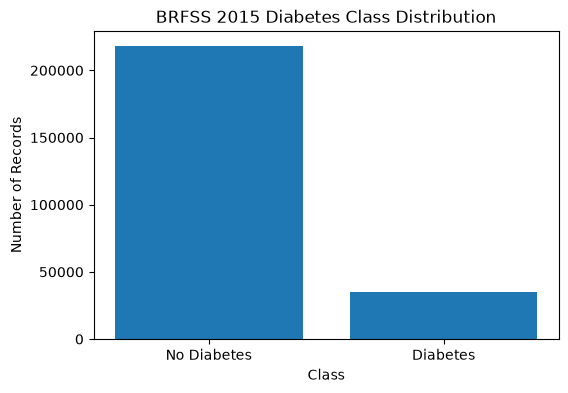

In [9]:
target_counts = df[target].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(
    ["No Diabetes", "Diabetes"],
    target_counts.values
)

plt.title("BRFSS 2015 Diabetes Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Records")

plt.show()

In [10]:
df[target].value_counts(normalize=True).mul(100).round(2)

Diabetes_binary
0.0    86.07
1.0    13.93
Name: proportion, dtype: float64

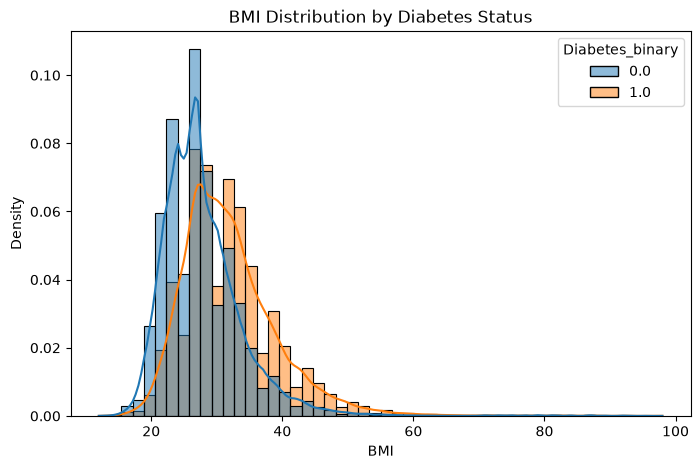

In [11]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="BMI",
    hue="Diabetes_binary",
    bins=50,
    kde=True,
    stat="density",
    common_norm=False
)

plt.title("BMI Distribution by Diabetes Status")
plt.show()

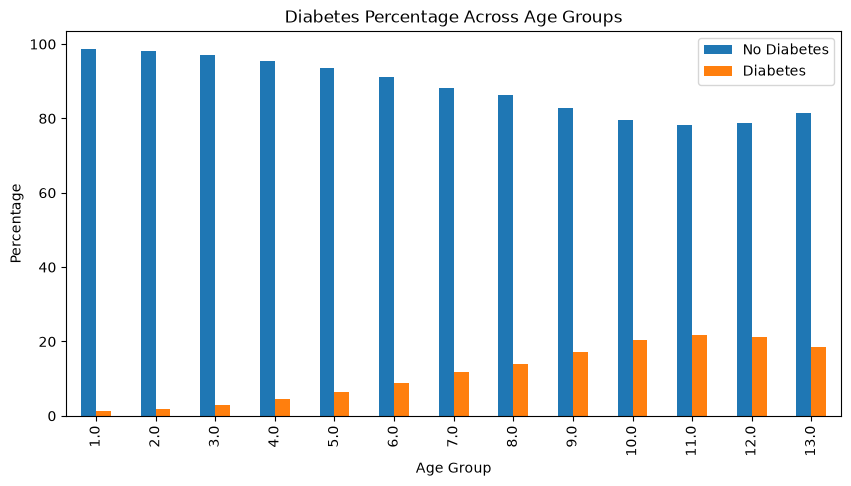

In [12]:
age_diabetes = pd.crosstab(
    df["Age"],
    df["Diabetes_binary"],
    normalize="index"
) * 100

age_diabetes.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Diabetes Percentage Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Percentage")

plt.legend(["No Diabetes", "Diabetes"])
plt.show()

In [13]:
feature_diabetes_rates = {}

for column in binary_features + ordinal_features:
    rates = (
        df.groupby(column)["Diabetes_binary"]
        .mean()
        .mul(100)
        .round(2)
    )

    feature_diabetes_rates[column] = rates

In [14]:
feature_diabetes_rates["HighBP"]

HighBP
0.0     6.04
1.0    24.45
Name: Diabetes_binary, dtype: float64

In [15]:
feature_diabetes_rates["HighChol"]

HighChol
0.0     7.98
1.0    22.01
Name: Diabetes_binary, dtype: float64

In [16]:
feature_diabetes_rates["PhysActivity"]

PhysActivity
0.0    21.14
1.0    11.61
Name: Diabetes_binary, dtype: float64

In [17]:
feature_diabetes_rates["GenHlth"]

GenHlth
1.0     2.52
2.0     7.16
3.0    17.79
4.0    31.01
5.0    37.89
Name: Diabetes_binary, dtype: float64

In [18]:
feature_diabetes_rates["Age"]

Age
1.0      1.37
2.0      1.84
3.0      2.82
4.0      4.53
5.0      6.50
6.0      8.79
7.0     11.74
8.0     13.83
9.0     17.25
10.0    20.37
11.0    21.85
12.0    21.30
13.0    18.48
Name: Diabetes_binary, dtype: float64

In [19]:
correlation_with_target = (
    df.corr(numeric_only=True)["Diabetes_binary"]
    .drop("Diabetes_binary")
    .sort_values()
)

correlation_with_target

Income                 -0.163919
Education              -0.124456
PhysActivity           -0.118133
HvyAlcoholConsump      -0.057056
Veggies                -0.056584
Fruits                 -0.040779
AnyHealthcare           0.016255
Sex                     0.031430
NoDocbcCost             0.031433
Smoker                  0.060789
CholCheck               0.064761
MentHlth                0.069315
Stroke                  0.105816
PhysHlth                0.171337
HeartDiseaseorAttack    0.177282
Age                     0.177442
HighChol                0.200276
BMI                     0.216843
DiffWalk                0.218344
HighBP                  0.263129
GenHlth                 0.293569
Name: Diabetes_binary, dtype: float64

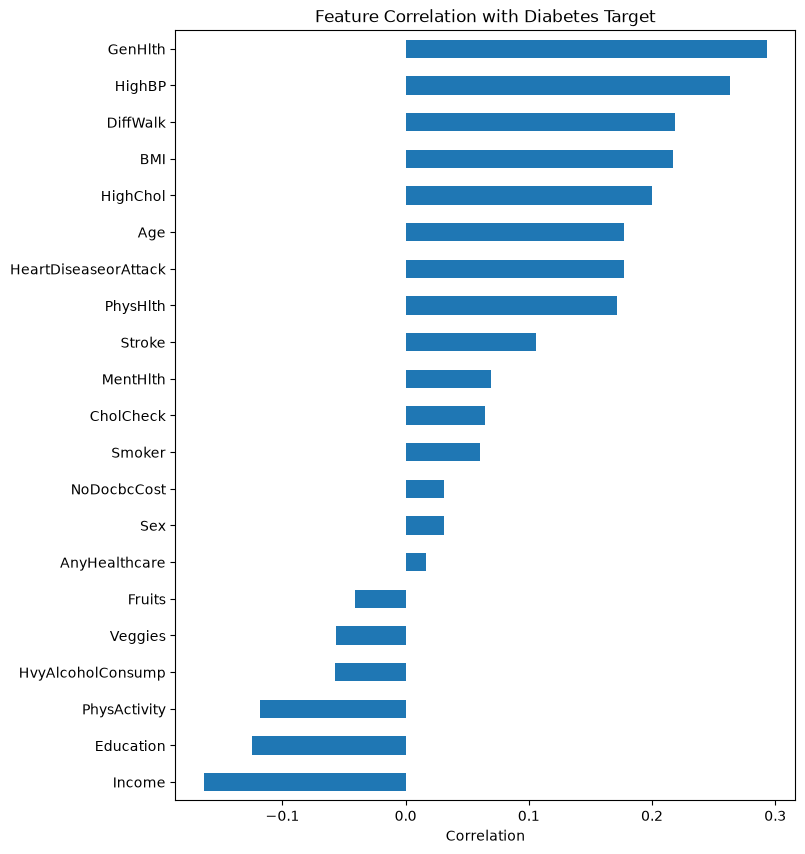

In [20]:
plt.figure(figsize=(8, 10))

correlation_with_target.sort_values().plot(kind="barh")

plt.title("Feature Correlation with Diabetes Target")
plt.xlabel("Correlation")

plt.show()